# Find stations and historical files

Learn how to search the station catalog, map a region, and identify available archive files before downloading observations.

Saved outputs use NOAA observations. Execution began 2026-09-10 13:38 UTC. Re-running requests current upstream data.

In [1]:
import matplotlib.pyplot as plt
import xndbc

bounds = {"north": 46, "south": 20, "west": -125, "east": -115}
years = range(1998, 2000)

## Search by text or station ID

Text search is case-insensitive and checks station IDs, names, owners, and station types. If you already know the IDs, pass them directly.

In [2]:
xndbc.stations.search(query="Boston")

<xarray.Dataset> Size: 13kB
Dimensions:       (station_id: 3)
Coordinates:
  * station_id    (station_id) <U7 84B '44013' '44403' 'bhbm3'
    latitude      (station_id) float64 24B 42.35 41.93 42.35
    longitude     (station_id) float64 24B -70.65 -61.66 -71.05
Data variables:
    name          (station_id) <U76 912B 'BOSTON 16 NM East of Boston, MA' .....
    owner         (station_id) <U3 36B 'N' 'N' 'O'
    station_type  (station_id) <U40 480B '2.1-meter ionomer foam buoy' ... 'W...
    notes         (station_id) <U990 12kB 'Caution: Right whales may be activ...
Attributes:
    source:   https://www.ndbc.noaa.gov/data/stations/station_table.txt

In [3]:
xndbc.stations.search(["44013", "41043"])

<xarray.Dataset> Size: 9kB
Dimensions:       (station_id: 2)
Coordinates:
  * station_id    (station_id) <U7 56B '44013' '41043'
    latitude      (station_id) float64 16B 42.35 21.09
    longitude     (station_id) float64 16B -70.65 -64.86
Data variables:
    name          (station_id) <U76 608B 'BOSTON 16 NM East of Boston, MA' 'N...
    owner         (station_id) <U3 24B 'N' 'N'
    station_type  (station_id) <U40 320B '2.1-meter ionomer foam buoy' '3-met...
    notes         (station_id) <U990 8kB 'Caution: Right whales may be active...
Attributes:
    source:   https://www.ndbc.noaa.gov/data/stations/station_table.txt

## Find and map a region

Bounds use four named coordinates in degrees. Here they describe a region near California. A west bound greater than the east bound selects across the dateline.

These are catalog positions, which may differ from historical deployment positions.

In [4]:
region = xndbc.stations.search(bounds=bounds)
region

<xarray.Dataset> Size: 860kB
Dimensions:       (station_id: 192)
Coordinates:
  * station_id    (station_id) <U7 5kB '1801583' '1801589' ... 'tlbo3' 'upbc1'
    latitude      (station_id) float64 2kB 37.36 37.36 37.36 ... 45.55 38.04
    longitude     (station_id) float64 2kB -122.9 -122.9 ... -123.9 -122.1
Data variables:
    name          (station_id) <U76 58kB 'SD 1063 - 24 NM SSW of San Francisc...
    owner         (station_id) <U3 2kB 'N' 'N' 'N' 'N' ... 'NR' 'NR' 'O' 'PT'
    station_type  (station_id) <U40 31kB 'Uncrewed Surface Vehicle' ... 'Wate...
    notes         (station_id) <U990 760kB 'SD-1063 was replaced on 1200Z, 7/...
Attributes:
    source:   https://www.ndbc.noaa.gov/data/stations/station_table.txt

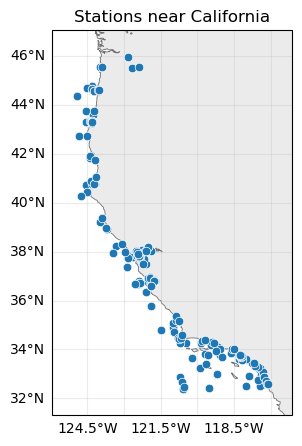

In [5]:
fig, ax = xndbc.stations.plot_map(region, labels=False)
ax.set_title("Stations near California")
plt.show()

## Inspect archive availability

Availability has `station_id` and `year` dimensions. `available` indicates file presence, and `url` identifies the file. A file can exist without containing the measurement you want.

In [6]:
available = xndbc.stations.availability(bounds=bounds, years=years)
available

<xarray.Dataset> Size: 96kB
Dimensions:       (station_id: 160, year: 2)
Coordinates:
  * station_id    (station_id) <U5 3kB '46011' '46012' ... 'tlbo3' 'upbc1'
    latitude      (station_id) float64 1kB 34.94 37.36 38.23 ... 45.55 38.04
    longitude     (station_id) float64 1kB -121.0 -122.9 ... -123.9 -122.1
    name          (station_id) object 1kB 'SANTA MARIA - 21NM NW of Point Arg...
    owner         (station_id) object 1kB 'N' 'N' 'N' 'N' ... 'CN' 'CN' 'O' 'PT'
    station_type  (station_id) object 1kB '3-meter discus buoy w/ seal cage' ...
    notes         (station_id) object 1kB '' ... ''
  * year          (year) int64 16B 1998 1999
    mode          <U6 24B 'stdmet'
Data variables:
    available     (station_id, year) bool 320B True True True ... False False
    url           (station_id, year) <U66 84kB 'https://www.ndbc.noaa.gov/dat...
Attributes:
    source:       https://www.ndbc.noaa.gov/data/historical/stdmet/
    description:  Archive file presence, not measurement completeness

## Select stations with at least one file

Reduce the availability array over `year`, then use that boolean array to select station IDs. This is a normal xarray selection; the IDs can be passed directly to `fetch_historical()`.

In [7]:
has_files = available.available.any("year")
station_ids = available.station_id.isel(station_id=has_files)
station_ids

<xarray.DataArray 'station_id' (station_id: 23)> Size: 460B
array(['46011', '46012', '46013', '46014', '46022', '46023', '46025', '46026',
       '46027', '46028', '46030', '46042', '46045', '46047', '46050', '46053',
       '46054', '46062', '46063', 'caro3', 'nwpo3', 'ptac1', 'ptgc1'],
      dtype='<U5')
Coordinates:
  * station_id    (station_id) <U5 460B '46011' '46012' ... 'ptac1' 'ptgc1'
    latitude      (station_id) float64 184B 34.94 37.36 38.23 ... 38.95 34.58
    longitude     (station_id) float64 184B -121.0 -122.9 ... -123.7 -120.6
    name          (station_id) object 184B 'SANTA MARIA - 21NM NW of Point Ar...
    owner         (station_id) object 184B 'N' 'N' 'N' 'N' ... 'N' 'N' 'N' 'N'
    station_type  (station_id) object 184B '3-meter discus buoy w/ seal cage'...
    notes         (station_id) object 184B '' ... ''
    mode          <U6 24B 'stdmet'

Choosing stations this way allows missing individual years. Downloads report those missing files through `data.ndbc.report()`. If you change the region or years, inspect the selection before downloading; it may be empty.

Continue with historical analysis for a small, explicit station selection and an introduction to coverage.